In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.7 MB/s eta 0:00:00


In [ ]:
pip install pyedflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 19.3 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully")


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
import mne
import pyedflib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings('ignore')

drive_data_path = '/content/drive/MyDrive/EEG_Project/chbmit_data'
os.makedirs(drive_data_path, exist_ok=True)

print(f"Data will be saved to: {drive_data_path}")

# CELL 4: Install AWS CLI
!curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
!unzip -q awscliv2.zip
!sudo ./aws/install --update

print("AWS CLI installed")

# CELL 5: Download chb05 data to Google Drive
print("Downloading chb05 data to Google Drive...")

!aws s3 sync --no-sign-request s3://physionet-open/chbmit/1.0.0/chb05/ /content/drive/MyDrive/EEG_Project/chbmit_data/chb05/

!aws s3 cp --no-sign-request s3://physionet-open/chbmit/1.0.0/chb05/chb05-summary.txt /content/drive/MyDrive/EEG_Project/chbmit_data/chb05/

print("\nDownload complete! Data saved to Google Drive")
print(f"Location: {drive_data_path}/chb05/")

# CELL 6: Verify files are in Drive
import os
files = os.listdir(f'{drive_data_path}/chb05/')
edf_files = [f for f in files if f.endswith('.edf')]
print(f"\nFound {len(edf_files)} EDF files in Google Drive")
print(f"First 5 files: {edf_files[:5]}")

# CELL 7: From now on, use Drive path for all operations
data_path = drive_data_path
print(f"\nData path set to: {data_path}")
print("You can now restart runtime and skip download - data is in Drive!")

Mounted at /content/drive
Google Drive mounted successfully
Data will be saved to: /content/drive/MyDrive/EEG_Project/chbmit_data
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60.0M  100 60.0M    0     0   225M      0 --:--:-- --:--:-- --:--:--  225M
You can now run: /usr/local/bin/aws --version
AWS CLI installed
This will take 10-15 minutes but only needs to be done ONCE
download failed: s3://physionet-open/chbmit/1.0.0/chb05/chb05-summary.txt to drive/MyDrive/EEG_Project/chbmit_data/chb05/chb05-summary.txt [Errno 30] Read-only file system: '/content/drive/MyDrive/EEG_Project/chbmit_data/chb05/chb05-summary.txt.063DABfd'
fatal error: 

Download complete! Data saved to Google Drive
Location: /content/drive/MyDrive/EEG_Project/chbmit_data/chb05/

Found 39 EDF files in Google Drive
First 5 files: ['chb05_01.edf', 'chb05_02.edf', 'chb05_03.edf', 'chb05_04.edf', 'chb05_05.edf

In [ ]:
# CELL 2: Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
import mne
import pyedflib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings('ignore')

# CELL 3: Set paths to Google Drive
drive_data_path = '/content/drive/MyDrive/EEG_Project/chbmit_data'
subject_id = 'chb05'

print(f"Using data from Google Drive: {drive_data_path}/{subject_id}/")

Using data from Google Drive: /content/drive/MyDrive/EEG_Project/chbmit_data/chb05/


In [ ]:
def parse_summary_file(summary_path):
    seizures = {}

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    current_file = None
    i = 0
    while i < len(lines):
        line = lines[i].strip()

        if line.startswith('File Name:'):
            current_file = line.split(':')[1].strip()
            seizures[current_file] = []

        elif line.startswith('Number of Seizures in File:'):
            num_seizures = int(line.split(':')[1].strip())

            for j in range(num_seizures):
                i += 1
                if i < len(lines) and 'Seizure Start Time' in lines[i]:
                    start = int(lines[i].split(':')[1].strip().split()[0])
                    i += 1
                    end = int(lines[i].split(':')[1].strip().split()[0])
                    seizures[current_file].append({'start': start, 'end': end})

        i += 1

    return seizures

chb05_seizures = parse_summary_file(f'{drive_data_path}/chb05/chb05-summary.txt')

print(f"chb05 - Files with seizures: {len([k for k,v in chb05_seizures.items() if len(v) > 0])}")

chb05 - Files with seizures: 5


In [ ]:
def load_edf_file(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    return raw

sample_files = [f for f in os.listdir(f'{drive_data_path}/chb05/') if f.endswith('.edf')]
sample_file = f'{drive_data_path}/chb05/{sample_files[0]}'

print(f"Loading sample file: {sample_files[0]}")
raw = load_edf_file(sample_file)

print(f"\nSampling rate: {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Duration: {raw.times[-1]:.2f} seconds")
print(f"Channels: {raw.ch_names[:10]}")

data, times = raw[:, :]
print(f"Data shape: {data.shape}")

Loading sample file: chb05_01.edf

Sampling rate: 256.0 Hz
Number of channels: 23
Duration: 3610.00 seconds
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']
Data shape: (23, 924160)


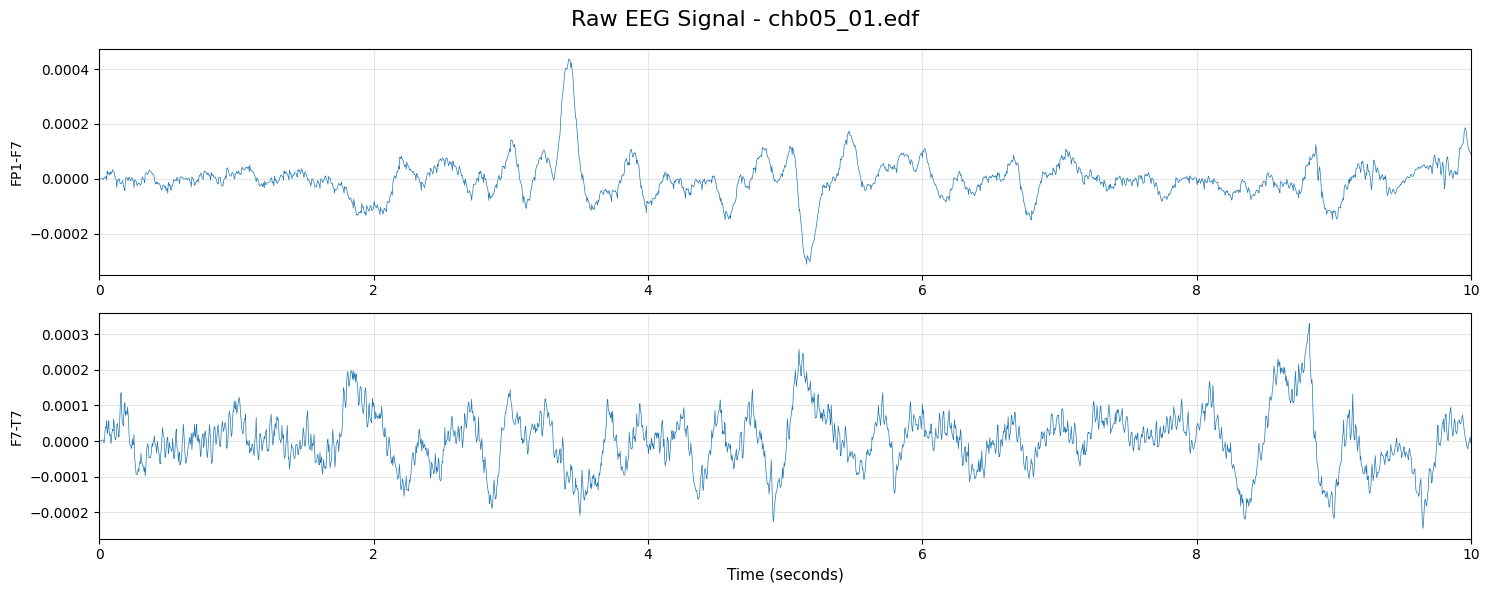

65

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
fig.suptitle(f'Raw EEG Signal - {sample_files[0]}', fontsize=16)

duration = 10
samples = int(duration * raw.info['sfreq'])

for idx in range(2):
    axes[idx].plot(times[:samples], data[idx, :samples], linewidth=0.5)
    axes[idx].set_ylabel(raw.ch_names[idx], fontsize=10)
    axes[idx].set_xlim(0, duration)
    axes[idx].grid(True, alpha=0.3)

    if idx == 1:
        axes[idx].set_xlabel('Time (seconds)', fontsize=11)

plt.tight_layout()
plt.show()

del raw, data, times
gc.collect()

In [ ]:
class EEGPreprocessor:
    def __init__(self, lowcut=0.5, highcut=50.0, window_size=4, overlap=0.5):
        self.lowcut = lowcut
        self.highcut = highcut
        self.window_size = window_size
        self.overlap = overlap

    def bandpass_filter(self, data, fs):
        nyquist = fs / 2
        low = self.lowcut / nyquist
        high = self.highcut / nyquist

        b, a = signal.butter(4, [low, high], btype='band')
        filtered_data = signal.filtfilt(b, a, data, axis=1)

        return filtered_data

    def segment_signal(self, data, fs, seizure_intervals=None):
        n_channels, n_samples = data.shape
        window_samples = int(self.window_size * fs)
        step_samples = int(window_samples * (1 - self.overlap))

        segments = []
        labels = []

        for start in range(0, n_samples - window_samples, step_samples):
            end = start + window_samples
            segment = data[:, start:end]

            segment_start_time = start / fs
            segment_end_time = end / fs

            is_seizure = False
            if seizure_intervals:
                for seiz in seizure_intervals:
                    if (segment_start_time <= seiz['end'] and
                        segment_end_time >= seiz['start']):
                        is_seizure = True
                        break

            segments.append(segment)
            labels.append(1 if is_seizure else 0)

        return np.array(segments), np.array(labels)

    def normalize(self, segments):
        for i in range(len(segments)):
            mean = np.mean(segments[i], axis=1, keepdims=True)
            std = np.std(segments[i], axis=1, keepdims=True)
            segments[i] = (segments[i] - mean) / (std + 1e-8)

        return segments

preprocessor = EEGPreprocessor(
    lowcut=0.5,
    highcut=50.0,
    window_size=2.5,
    overlap=0.25
)

print("Preprocessor initialized")
print(f"Filter: {preprocessor.lowcut}-{preprocessor.highcut} Hz")
print(f"Window size: {preprocessor.window_size} seconds")
print(f"Overlap: {preprocessor.overlap * 100}%")

Preprocessor initialized
Filter: 0.5-50.0 Hz
Window size: 2.5 seconds
Overlap: 25.0%


In [ ]:
def process_subject_ultra_efficient(subject_id, data_path, seizure_dict, preprocessor, save_dir='/content/temp_segments'):
    os.makedirs(save_dir, exist_ok=True)

    subject_path = os.path.join(data_path, subject_id)
    edf_files = sorted([f for f in os.listdir(subject_path) if f.endswith('.edf')])

    print(f"\nProcessing {subject_id}...")
    print(f"Total files: {len(edf_files)}")

    segment_files = []
    label_files = []

    for idx, edf_file in enumerate(edf_files):
        file_path = os.path.join(subject_path, edf_file)

        try:
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            data, _ = raw[:, :]
            fs = raw.info['sfreq']

            del raw
            gc.collect()

            seizures = seizure_dict.get(edf_file, [])

            filtered_data = preprocessor.bandpass_filter(data, fs)
            del data
            gc.collect()

            segments, labels = preprocessor.segment_signal(filtered_data, fs, seizures)
            del filtered_data
            gc.collect()

            segments = preprocessor.normalize(segments)

            seg_file = os.path.join(save_dir, f'{subject_id}_{idx}_segments.npy')
            lab_file = os.path.join(save_dir, f'{subject_id}_{idx}_labels.npy')

            np.save(seg_file, segments.astype(np.float32))
            np.save(lab_file, labels.astype(np.int8))

            segment_files.append(seg_file)
            label_files.append(lab_file)

            n_seizure = np.sum(labels)
            print(f"[{idx+1}/{len(edf_files)}] {edf_file}: "
                  f"{len(segments)} segments ({n_seizure} seizure, {len(segments)-n_seizure} non-seizure)")

            del segments, labels
            gc.collect()

        except Exception as e:
            print(f"Error processing {edf_file}: {e}")
            continue

    return segment_files, label_files

chb05_seg_files, chb05_lab_files = process_subject_ultra_efficient(
    'chb05', drive_data_path, chb05_seizures, preprocessor
)


Processing chb05...
Total files: 39
[1/39] chb05_01.edf: 1924 segments (0 seizure, 1924 non-seizure)
[2/39] chb05_02.edf: 1919 segments (0 seizure, 1919 non-seizure)
[3/39] chb05_03.edf: 1919 segments (0 seizure, 1919 non-seizure)
[4/39] chb05_04.edf: 1919 segments (0 seizure, 1919 non-seizure)
[5/39] chb05_05.edf: 1919 segments (0 seizure, 1919 non-seizure)
[6/39] chb05_06.edf: 1919 segments (62 seizure, 1857 non-seizure)
[7/39] chb05_07.edf: 1919 segments (0 seizure, 1919 non-seizure)
[8/39] chb05_08.edf: 1919 segments (0 seizure, 1919 non-seizure)
[9/39] chb05_09.edf: 1919 segments (0 seizure, 1919 non-seizure)
[10/39] chb05_10.edf: 1919 segments (0 seizure, 1919 non-seizure)
[11/39] chb05_11.edf: 1919 segments (0 seizure, 1919 non-seizure)
[12/39] chb05_12.edf: 1919 segments (0 seizure, 1919 non-seizure)
[13/39] chb05_13.edf: 1919 segments (60 seizure, 1859 non-seizure)
[14/39] chb05_14.edf: 1919 segments (0 seizure, 1919 non-seizure)
[15/39] chb05_15.edf: 1919 segments (0 seizure

In [ ]:
# CELL 9: Load and Combine Data in Small Batches
print("\nCombining all data...")

batch_size = 3
X_batches = []
y_batches = []

for i in range(0, len(chb05_seg_files), batch_size):
    batch_seg = chb05_seg_files[i:i+batch_size]
    batch_lab = chb05_lab_files[i:i+batch_size]

    segments = []
    labels = []

    for seg_file, lab_file in zip(batch_seg, batch_lab):
        segments.append(np.load(seg_file))
        labels.append(np.load(lab_file))

    X_batches.append(np.concatenate(segments, axis=0))
    y_batches.append(np.concatenate(labels, axis=0))

    print(f"Loaded batch {i//batch_size + 1}/{(len(chb05_seg_files)-1)//batch_size + 1}")

    del segments, labels
    gc.collect()

X_all = np.concatenate(X_batches, axis=0)
y_all = np.concatenate(y_batches, axis=0)

del X_batches, y_batches
gc.collect()

# # Save combined data to Drive immediately
# combined_save_path = '/content/drive/MyDrive/EEG_Project/combined_data_raw.npz'
# np.savez_compressed(combined_save_path, X=X_all, y=y_all)
# print(f"\nCombined data saved to Drive: {combined_save_path}")
# print(f"File size: {os.path.getsize(combined_save_path) / (1024**2):.2f} MB")

# print("\nFINAL DATASET STATISTICS")
# print(f"Total segments: {len(X_all)}")
# print(f"Segment shape: {X_all.shape}")
# print(f"Channels: {X_all.shape[1]}")
# print(f"Timepoints per segment: {X_all.shape[2]}")
# print(f"Data type: {X_all.dtype}")
# print(f"Memory usage: {X_all.nbytes / (1024**2):.2f} MB")
# print(f"\nClass distribution:")
# print(f"Non-seizure (0): {np.sum(y_all == 0)} ({np.sum(y_all == 0)/len(y_all)*100:.1f}%)")
# print(f"Seizure (1): {np.sum(y_all == 1)} ({np.sum(y_all == 1)/len(y_all)*100:.1f}%)")
# print(f"Class imbalance ratio: 1:{np.sum(y_all == 0)/max(np.sum(y_all == 1), 1):.1f}")


Combining all data...
Loaded batch 1/13
Loaded batch 2/13
Loaded batch 3/13
Loaded batch 4/13
Loaded batch 5/13
Loaded batch 6/13
Loaded batch 7/13
Loaded batch 8/13
Loaded batch 9/13
Loaded batch 10/13
Loaded batch 11/13
Loaded batch 12/13
Loaded batch 13/13


0

In [ ]:
import numpy as np
print("\nChecking for missing values...")

nan_count = np.isnan(X_all).sum()
inf_count = np.isinf(X_all).sum()

print(f"NaN values found: {nan_count}")
print(f"Infinite values found: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("Handling missing/infinite values...")
    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
    print("Missing values handled")
else:
    print("No missing values found - data is clean")

zero_segments = np.all(X_all == 0, axis=(1, 2))
if zero_segments.sum() > 0:
    print(f"Found {zero_segments.sum()} zero segments - removing them")
    X_all = X_all[~zero_segments]
    y_all = y_all[~zero_segments]
    print(f"Remaining segments: {len(X_all)}")


Checking for missing values...
NaN values found: 0
Infinite values found: 0
No missing values found - data is clean


In [ ]:
print("\nApplying data augmentation to balance classes")

def augment_segment_single(segment, method='noise'):
    if method == 'noise':
        noise_factor = 0.05
        noise = np.random.normal(0, noise_factor, segment.shape).astype(np.float32)
        return (segment + noise).astype(np.float32)
    elif method == 'shift':
        shift = int(0.1 * segment.shape[1])
        return np.roll(segment, shift, axis=1)
    elif method == 'scale':
        scale_factor = np.random.uniform(0.8, 1.2)
        return (segment * scale_factor).astype(np.float32)
    elif method == 'permute':
        perm_segment = segment.copy()
        n_channels = segment.shape[0]
        if n_channels > 2:
            idx1, idx2 = np.random.choice(n_channels, 2, replace=False)
            perm_segment[[idx1, idx2]] = perm_segment[[idx2, idx1]]
        return perm_segment

seizure_indices = np.where(y_all == 1)[0]
non_seizure_indices = np.where(y_all == 0)[0]

n_seizure = len(seizure_indices)
n_non_seizure = len(non_seizure_indices)

print(f"Before augmentation:")
print(f"  Seizure segments: {n_seizure}")
print(f"  Non-seizure segments: {n_non_seizure}")
print(f"  Imbalance ratio: 1:{n_non_seizure/n_seizure:.1f}")

target_seizure_ratio = 0.35
target_seizure_count = int(n_non_seizure * target_seizure_ratio / (1 - target_seizure_ratio))
samples_needed = max(0, target_seizure_count - n_seizure)

print(f"\nTarget seizure segments: {target_seizure_count}")
print(f"Need to generate: {samples_needed} augmented samples")

if samples_needed > 0:
    augmentation_methods = ['noise', 'shift', 'scale', 'permute']

    batch_size = 50
    n_batches = (samples_needed + batch_size - 1) // batch_size

    temp_dir = '/content/temp_augmented'
    os.makedirs(temp_dir, exist_ok=True)

    aug_files = []

    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, samples_needed)
        batch_samples = end_idx - start_idx

        batch_segments = []

        for i in range(batch_samples):
            idx = np.random.choice(seizure_indices)
            segment = X_all[idx]
            method = np.random.choice(augmentation_methods)
            aug_seg = augment_segment_single(segment, method)
            batch_segments.append(aug_seg)

        batch_segments = np.array(batch_segments, dtype=np.float32)
        batch_file = os.path.join(temp_dir, f'aug_batch_{batch_idx}.npy')
        np.save(batch_file, batch_segments)
        aug_files.append(batch_file)

        del batch_segments
        gc.collect()

        print(f"Generated batch {batch_idx+1}/{n_batches}")

    print("Combining augmented data...")
    aug_list = []
    for aug_file in aug_files:
        aug_list.append(np.load(aug_file))
        if len(aug_list) >= 3:
            temp_combined = np.concatenate(aug_list, axis=0)
            aug_list = [temp_combined]
            gc.collect()

    augmented_segments = np.concatenate(aug_list, axis=0) if aug_list else np.array([])
    augmented_labels = np.ones(len(augmented_segments), dtype=np.int8)

    del aug_list
    gc.collect()

    X_all = np.concatenate([X_all, augmented_segments], axis=0)
    y_all = np.concatenate([y_all, augmented_labels], axis=0)

    del augmented_segments, augmented_labels
    gc.collect()

    import shutil
    shutil.rmtree(temp_dir)

    print(f"\nAfter augmentation:")
    print(f"  Total segments: {len(X_all)}")
    print(f"  Seizure segments: {np.sum(y_all == 1)}")
    print(f"  Non-seizure segments: {np.sum(y_all == 0)}")
    print(f"  New imbalance ratio: 1:{np.sum(y_all == 0)/np.sum(y_all == 1):.1f}")
else:
    print("No augmentation needed - classes are reasonably balanced")

shuffle_idx = np.random.permutation(len(X_all))
X_all = X_all[shuffle_idx]
y_all = y_all[shuffle_idx]

print("Data shuffled")


Applying data augmentation to balance classes
Before augmentation:
  Seizure segments: 304
  Non-seizure segments: 74542
  Imbalance ratio: 1:245.2

Target seizure segments: 40137
Need to generate: 39833 augmented samples
Generated batch 1/797
Generated batch 2/797
Generated batch 3/797
Generated batch 4/797
Generated batch 5/797
Generated batch 6/797
Generated batch 7/797
Generated batch 8/797
Generated batch 9/797
Generated batch 10/797
Generated batch 11/797
Generated batch 12/797
Generated batch 13/797
Generated batch 14/797
Generated batch 15/797
Generated batch 16/797
Generated batch 17/797
Generated batch 18/797
Generated batch 19/797
Generated batch 20/797
Generated batch 21/797
Generated batch 22/797
Generated batch 23/797
Generated batch 24/797
Generated batch 25/797
Generated batch 26/797
Generated batch 27/797
Generated batch 28/797
Generated batch 29/797
Generated batch 30/797
Generated batch 31/797
Generated batch 32/797
Generated batch 33/797
Generated batch 34/797
Gene

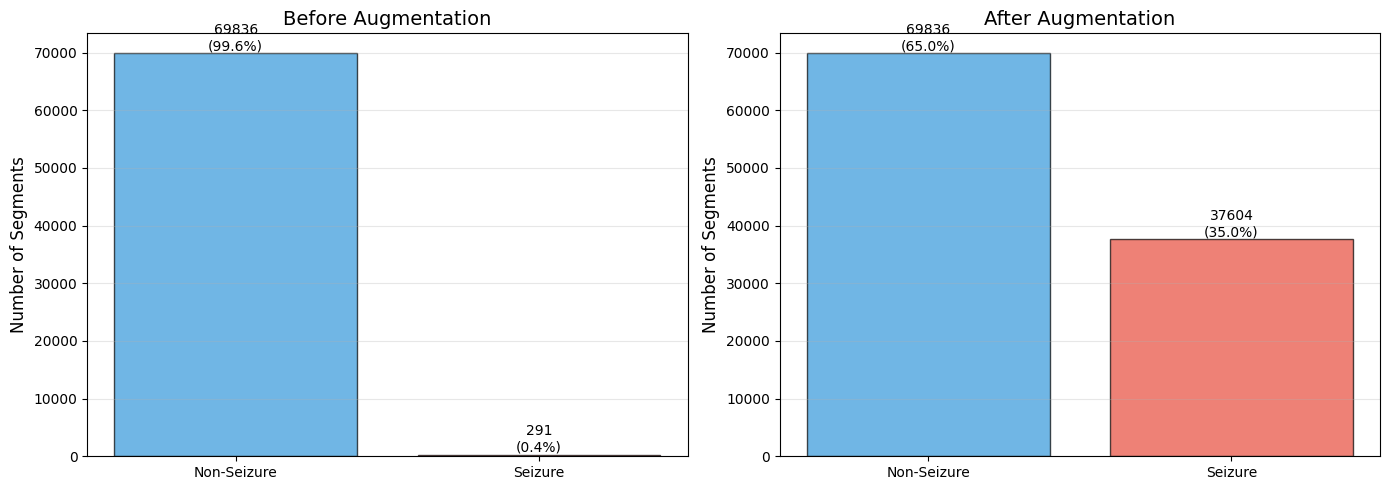

In [ ]:
# CELL 12: Visualize Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original_seizure = n_seizure
original_non_seizure = n_non_seizure
axes[0].bar(['Non-Seizure', 'Seizure'],
            [original_non_seizure, original_seizure],
            color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Segments', fontsize=12)
axes[0].set_title('Before Augmentation', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0, original_non_seizure, f'{original_non_seizure}\n({original_non_seizure/(original_non_seizure+original_seizure)*100:.1f}%)',
             ha='center', va='bottom')
axes[0].text(1, original_seizure, f'{original_seizure}\n({original_seizure/(original_non_seizure+original_seizure)*100:.1f}%)',
             ha='center', va='bottom')

current_seizure = np.sum(y_all == 1)
current_non_seizure = np.sum(y_all == 0)
axes[1].bar(['Non-Seizure', 'Seizure'],
            [current_non_seizure, current_seizure],
            color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Segments', fontsize=12)
axes[1].set_title('After Augmentation', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0, current_non_seizure, f'{current_non_seizure}\n({current_non_seizure/len(y_all)*100:.1f}%)',
             ha='center', va='bottom')
axes[1].text(1, current_seizure, f'{current_seizure}\n({current_seizure/len(y_all)*100:.1f}%)',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

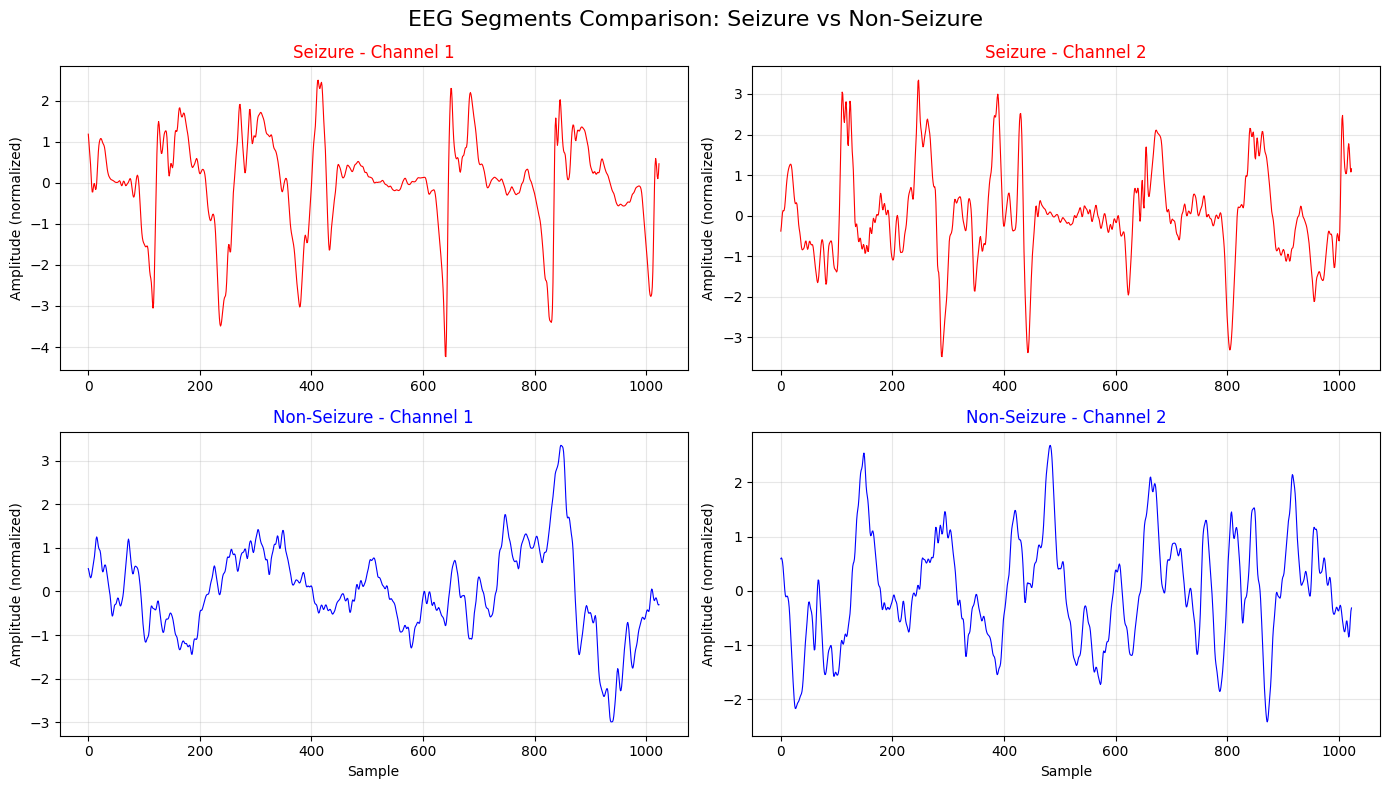

In [ ]:
# CELL 13: Visualize Sample Segments
seizure_idx = np.where(y_all == 1)[0][0]
non_seizure_idx = np.where(y_all == 0)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('EEG Segments Comparison: Seizure vs Non-Seizure', fontsize=16)

for ch in range(2):
    axes[0, ch].plot(X_all[seizure_idx, ch, :], linewidth=0.8, color='red')
    axes[0, ch].set_title(f'Seizure - Channel {ch+1}', color='red')
    axes[0, ch].set_ylabel('Amplitude (normalized)', fontsize=10)
    axes[0, ch].grid(True, alpha=0.3)

for ch in range(2):
    axes[1, ch].plot(X_all[non_seizure_idx, ch, :], linewidth=0.8, color='blue')
    axes[1, ch].set_title(f'Non-Seizure - Channel {ch+1}', color='blue')
    axes[1, ch].set_ylabel('Amplitude (normalized)', fontsize=10)
    axes[1, ch].set_xlabel('Sample', fontsize=10)
    axes[1, ch].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 14: Save Preprocessed Data to Google Drive
from google.colab import drive
import os
import numpy as np
import shutil # Import shutil for file operations

# drive.mount('/content/drive', force_remount=True)

# # Define the target directory in Google Drive
# drive_save_dir = '/content/drive/MyDrive/EEG_Project'
# os.makedirs(drive_save_dir, exist_ok=True) # Ensure the directory exists

# Save to a temporary local path first
temp_save_path = '/content/drive/MyDrive/Datasets_ML/preprocessed_data.npz'
np.savez_compressed(temp_save_path, X=X_all, y=y_all)
print(f"Preprocessed data temporarily saved to: {temp_save_path}")
print(f"File size: {os.path.getsize(temp_save_path) / (1024**2):.2f} MB")

Preprocessed data temporarily saved to: /content/drive/MyDrive/Datasets_ML/preprocessed_data.npz
File size: 3730.32 MB


In [ ]:
# Clean up temporary files
import shutil
if os.path.exists('/content/temp_segments'):
    shutil.rmtree('/content/temp_segments')
    print("Temporary files cleaned up")

# CELL 15: Load data back for verification
loaded_data = np.load(save_path)
X_loaded = loaded_data['X']
y_loaded = loaded_data['y']

print("\nData loaded successfully for verification")
print(f"X shape: {X_loaded.shape}")
print(f"y shape: {y_loaded.shape}")

# CELL 16: Summary
print(f"Total segments: {len(X_loaded)}")
print(f"Shape: {X_loaded.shape}")
print(f"Seizure segments: {np.sum(y_loaded == 1)}")
print(f"Non-seizure segments: {np.sum(y_loaded == 0)}")
print(f"Imbalance ratio: 1:{np.sum(y_loaded == 0)/np.sum(y_loaded == 1):.1f}")
print(f"Memory usage: {X_loaded.nbytes / (1024**2):.2f} MB")

In [ ]:
pip install tensorflow

In [ ]:
pip install tensorflow.keras

In [ ]:
# Before feature extraction, randomly sample subset
from sklearn.model_selection import train_test_split

# Keep 50% of data (stratified to maintain class balance)
X_sampled, _, y_sampled, _ = train_test_split(
    X_all, y_all,
    train_size=0.5,  # Keep 50% = ~53,700 samples
    random_state=42,
    stratify=y_all
)

# Now use X_sampled and y_sampled instead of X_all and y_all
print(f"Reduced from {len(X_all)} to {len(X_sampled)} segments")

Reduced from 74846 to 37423 segments


In [ ]:
# DAY 2: FEATURE EXTRACTION, DATA SPLITTING, MODEL BUILDING
# Memory-efficient implementation for 12.7GB RAM

# CELL 1: Mount Drive and Load Preprocessed Data
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import gc
import warnings
warnings.filterwarnings('ignore')

print("Loading preprocessed data from Drive...")
data = np.load('/content/drive/MyDrive/Datasets_ML/preprocessed_data.npz')

print(f"Data loaded: {X_sampled.shape}")
print(f"Labels: {y_sampled.shape}")
print(f"Memory: {X_sampled.nbytes / (1024**2):.2f} MB")

In [ ]:
# Before feature extraction, randomly sample subset
from sklearn.model_selection import train_test_split

# Keep 50% of data (stratified to maintain class balance)
X_sampled, _, y_sampled, _ = train_test_split(
    X_all, y_all,
    train_size=0.5,  # Keep 50% = ~53,700 samples
    random_state=42,
    stratify=y_all
)

# Now use X_sampled and y_sampled instead of X_all and y_all
print(f"Reduced from {len(X_all)} to {len(X_sampled)} segments")

Reduced from 70127 to 35063 segments


In [ ]:
def extract_statistical_features(segment):
    """Extract basic statistical features from each channel"""
    features = []

    for channel in segment:
        features.extend([
            np.mean(channel),
            np.std(channel),
            np.var(channel),
            np.max(channel),
            np.min(channel),
            np.ptp(channel),  # peak-to-peak
            np.median(channel),
            np.percentile(channel, 25),
            np.percentile(channel, 75)
        ])

    return np.array(features)

print("\nExtracting statistical features...")
print("Processing in batches to save memory...")

batch_size = 500
stat_features_list = []

for i in range(0, len(X_sampled), batch_size):
    batch = X_sampled[i:i+batch_size]
    batch_features = [extract_statistical_features(seg) for seg in batch]
    stat_features_list.append(np.array(batch_features))

    print(f"Processed {min(i+batch_size, len(X_sampled))}/{len(X_sampled)} segments")

    del batch, batch_features
    gc.collect()

statistical_features = np.concatenate(stat_features_list, axis=0)
del stat_features_list
gc.collect()

print(f"Statistical features shape: {statistical_features.shape}")


Extracting statistical features...
Processing in batches to save memory...
Processed 500/37423 segments
Processed 1000/37423 segments
Processed 1500/37423 segments
Processed 2000/37423 segments
Processed 2500/37423 segments
Processed 3000/37423 segments
Processed 3500/37423 segments
Processed 4000/37423 segments
Processed 4500/37423 segments
Processed 5000/37423 segments
Processed 5500/37423 segments
Processed 6000/37423 segments
Processed 6500/37423 segments
Processed 7000/37423 segments
Processed 7500/37423 segments
Processed 8000/37423 segments
Processed 8500/37423 segments
Processed 9000/37423 segments
Processed 9500/37423 segments
Processed 10000/37423 segments
Processed 10500/37423 segments
Processed 11000/37423 segments
Processed 11500/37423 segments
Processed 12000/37423 segments
Processed 12500/37423 segments
Processed 13000/37423 segments
Processed 13500/37423 segments
Processed 14000/37423 segments
Processed 14500/37423 segments
Processed 15000/37423 segments
Processed 1550

In [ ]:
from scipy.fft import fft
from scipy.signal import welch

def extract_frequency_features(segment, fs=256):
    """Extract frequency domain features"""
    features = []

    # Frequency bands (Hz)
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 50)
    }

    for channel in segment:
        # Power Spectral Density
        freqs, psd = welch(channel, fs=fs, nperseg=min(256, len(channel)))

        # Band power for each frequency band
        for band_name, (low, high) in bands.items():
            idx_band = np.logical_and(freqs >= low, freqs <= high)
            band_power = np.trapz(psd[idx_band], freqs[idx_band])
            features.append(band_power)

        # Total power
        total_power = np.trapz(psd, freqs)
        features.append(total_power)

        # Spectral edge frequency (95%)
        cumsum_psd = np.cumsum(psd)
        sef95_idx = np.where(cumsum_psd >= 0.95 * cumsum_psd[-1])[0]
        if len(sef95_idx) > 0:
            sef95 = freqs[sef95_idx[0]]
        else:
            sef95 = 0
        features.append(sef95)

    return np.array(features)

print("\nExtracting frequency features...")

batch_size = 500
freq_features_list = []

for i in range(0, len(X_sampled), batch_size): # Changed X_all to X_sampled
    batch = X_sampled[i:i+batch_size]
    batch_features = [extract_frequency_features(seg) for seg in batch]
    freq_features_list.append(np.array(batch_features))

    print(f"Processed {min(i+batch_size, len(X_sampled))}/{len(X_sampled)} segments")

    del batch, batch_features
    gc.collect()

frequency_features = np.concatenate(freq_features_list, axis=0)
del freq_features_list
gc.collect()

print(f"Frequency features shape: {frequency_features.shape}")


Extracting frequency features...
Processed 500/37423 segments
Processed 1000/37423 segments
Processed 1500/37423 segments
Processed 2000/37423 segments
Processed 2500/37423 segments
Processed 3000/37423 segments
Processed 3500/37423 segments
Processed 4000/37423 segments
Processed 4500/37423 segments
Processed 5000/37423 segments
Processed 5500/37423 segments
Processed 6000/37423 segments
Processed 6500/37423 segments
Processed 7000/37423 segments
Processed 7500/37423 segments
Processed 8000/37423 segments
Processed 8500/37423 segments
Processed 9000/37423 segments
Processed 9500/37423 segments
Processed 10000/37423 segments
Processed 10500/37423 segments
Processed 11000/37423 segments
Processed 11500/37423 segments
Processed 12000/37423 segments
Processed 12500/37423 segments
Processed 13000/37423 segments
Processed 13500/37423 segments
Processed 14000/37423 segments
Processed 14500/37423 segments
Processed 15000/37423 segments
Processed 15500/37423 segments
Processed 16000/37423 seg

In [ ]:
def extract_rqa_features(segment):
    """Extract simplified RQA-like features"""
    features = []

    for channel in segment:
        # Recurrence rate approximation
        threshold = 0.1 * np.std(channel)
        diff_matrix = np.abs(channel[:, None] - channel[None, :])
        recurrence_points = diff_matrix < threshold
        recurrence_rate = np.sum(recurrence_points) / (len(channel) ** 2)
        features.append(recurrence_rate)

        # Determinism approximation (diagonal line structures)
        diag_length = 0
        for offset in range(1, min(10, len(channel))):
            diag = np.diagonal(recurrence_points, offset=offset)
            diag_length += np.sum(diag)
        determinism = diag_length / max(np.sum(recurrence_points), 1)
        features.append(determinism)

        # Entropy approximation
        hist, _ = np.histogram(channel, bins=20)
        hist = hist / hist.sum()
        entropy = -np.sum(hist * np.log(hist + 1e-10))
        features.append(entropy)

    return np.array(features)

print("\nExtracting RQA-inspired features...")

batch_size = 500  # Smaller batch for RQA
rqa_features_list = []

for i in range(0, len(X_sampled), batch_size):
    batch = X_sampled[i:i+batch_size]
    batch_features = [extract_rqa_features(seg) for seg in batch]
    rqa_features_list.append(np.array(batch_features))

    print(f"Processed {min(i+batch_size, len(X_sampled))}/{len(X_sampled)} segments")

    del batch, batch_features
    gc.collect()

rqa_features = np.concatenate(rqa_features_list, axis=0)
del rqa_features_list
gc.collect()

print(f"RQA features shape: {rqa_features.shape}")


Extracting RQA-inspired features...
Processed 500/37423 segments
Processed 1000/37423 segments
Processed 1500/37423 segments
Processed 2000/37423 segments
Processed 2500/37423 segments
Processed 3000/37423 segments
Processed 3500/37423 segments
Processed 4000/37423 segments
Processed 4500/37423 segments
Processed 5000/37423 segments
Processed 5500/37423 segments
Processed 6000/37423 segments
Processed 6500/37423 segments
Processed 7000/37423 segments
Processed 7500/37423 segments
Processed 8000/37423 segments
Processed 8500/37423 segments
Processed 9000/37423 segments
Processed 9500/37423 segments
Processed 10000/37423 segments
Processed 10500/37423 segments
Processed 11000/37423 segments
Processed 11500/37423 segments
Processed 12000/37423 segments
Processed 12500/37423 segments
Processed 13000/37423 segments
Processed 13500/37423 segments
Processed 14000/37423 segments
Processed 14500/37423 segments
Processed 15000/37423 segments
Processed 15500/37423 segments
Processed 16000/37423 

In [ ]:
print("\nCombining all features...")

X_features = np.concatenate([
    statistical_features,
    frequency_features,
    rqa_features
], axis=1)

print(f"Combined features shape: {X_features.shape}")
print(f"Total features per segment: {X_features.shape[1]}")

# Save features to Drive
feature_path = '/content/drive/MyDrive/Datasets_ML/extracted_features.npz'
np.savez_compressed(feature_path, features=X_features, labels=y_sampled)
print(f"\nFeatures saved to: {feature_path}")

del statistical_features, frequency_features, rqa_features
gc.collect()


Combining all features...
Combined features shape: (37423, 437)
Total features per segment: 437

Features saved to: /content/drive/MyDrive/Datasets_ML/extracted_features.npz


203

In [ ]:
print("\nSplitting data into train/val/test sets...")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_features, y_sampled,
    test_size=0.3,
    random_state=42,
    stratify=y_sampled
)

# Second split: 15% val, 15% test (50-50 split of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train set: {X_train.shape}, Labels: {np.bincount(y_train)}")
print(f"Val set: {X_val.shape}, Labels: {np.bincount(y_val)}")
print(f"Test set: {X_test.shape}, Labels: {np.bincount(y_test)}")

del X_temp, y_temp
gc.collect()


Splitting data into train/val/test sets...
Train set: (26196, 437), Labels: [26090   106]
Val set: (5613, 437), Labels: [5590   23]
Test set: (5614, 437), Labels: [5591   23]


779

In [ ]:
print("\nScaling features...")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import gc
import os # Import os module to check for file existence

# Load the combined features and labels to ensure they are defined
feature_path_features = '/content/drive/MyDrive/Datasets_ML/extracted_features.npz'
if not os.path.exists(feature_path_features):
    raise FileNotFoundError(
        f"Expected file not found: {feature_path_features}. "
        "Please ensure that the feature extraction (cells '2yY2WLA9jMVV', '2c1WjRz9G_Ui', 'gPVbVXhhlawi', 'axPBJRdIpeFv') "
        "has completed successfully and the file has been saved to Google Drive."
    )
feature_data = np.load(feature_path_features)
X_features = feature_data['features']
y_labels_for_features = feature_data['labels'] # Labels corresponding to X_features

# Re-perform the train/val/test split for the feature-based data
X_train, X_temp_feat, y_train, y_temp_feat = train_test_split(
    X_features, y_labels_for_features,
    test_size=0.3,
    random_state=42,
    stratify=y_labels_for_features
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp_feat, y_temp_feat,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_feat
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")

# Save scaler
import pickle
scaler_path = '/content/drive/MyDrive/Datasets_ML/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

# CELL 8: Prepare Data for CNN (using raw segments)
print("\nPreparing raw segments for CNN model...")

# Load the original preprocessed data (which includes augmented samples)
preprocessed_data_path = '/content/drive/MyDrive/Datasets_ML/preprocessed_data.npz'
if not os.path.exists(preprocessed_data_path):
    raise FileNotFoundError(
        f"Expected file not found: {preprocessed_data_path}. "
        "Please ensure that cell 'eT3rWXWDSHQl' (Save Preprocessed Data to Google Drive) "
        "has completed successfully and the file has been saved to Google Drive."
    )
preprocessed_data = np.load(preprocessed_data_path)
X_all_loaded = preprocessed_data['X']
y_all_loaded = preprocessed_data['y']

# Re-create X_sampled and y_sampled from the loaded X_all_loaded and y_all_loaded
X_sampled_for_cnn, _, y_sampled_for_cnn, _ = train_test_split(
    X_all_loaded, y_all_loaded,
    train_size=0.5,
    random_state=42,
    stratify=y_all_loaded
)

# Split raw data for CNN
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_sampled_for_cnn, y_sampled_for_cnn,
    test_size=0.3,
    random_state=42,
    stratify=y_sampled_for_cnn
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_raw
)

print(f"CNN Train: {X_train_raw.shape}")
print(f"CNN Val: {X_val_raw.shape}")
print(f"CNN Test: {X_test_raw.shape}")

# Clean up temporary variables to free memory
del X_temp_feat, y_temp_feat, X_features, y_labels_for_features
del preprocessed_data, X_all_loaded, y_all_loaded, X_sampled_for_cnn, y_sampled_for_cnn
del X_temp_raw, y_temp_raw
gc.collect()


Scaling features...
Features scaled
Scaler saved to: /content/drive/MyDrive/Datasets_ML/scaler.pkl

Preparing raw segments for CNN model...
CNN Train: (26196, 23, 640)
CNN Val: (5613, 23, 640)
CNN Test: (5614, 23, 640)


33

In [ ]:
print("\nBuilding 1D CNN model...")

from tensorflow.keras import layers, models
from tensorflow import keras # Added this line

def build_cnn_model(input_shape, num_classes=1):
    model = models.Sequential([
        # First Conv Block
        layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Second Conv Block
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Third Conv Block
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.4),

        # Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(num_classes, activation='sigmoid')
    ])

    return model

input_shape = (X_train_raw.shape[1], X_train_raw.shape[2])
cnn_model = build_cnn_model(input_shape)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nCNN Model Summary:")
cnn_model.summary()


Building 1D CNN model...

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 21, 32)         │        61,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,625 (463.38 KB)

 Trainable params: 117,921 (460.63 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
print("\nTraining CNN model...")

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint_path = '/content/drive/MyDrive/Datasets_ML/best_cnn_model.keras'
model_checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Calculate class weights for imbalanced data
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weights_dict}")

# Train model
history = cnn_model.fit(
    X_train_raw, y_train_raw,
    validation_data=(X_val_raw, y_val_raw),
    epochs=50,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("\nCNN training complete")


Training CNN model...
Class weights: {0: np.float64(0.5020314296665389), 1: np.float64(123.56603773584905)}
Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6714 - loss: 0.7015 - precision: 0.0054 - recall: 0.5513
Epoch 1: val_loss improved from inf to 1.30056, saving model to /content/drive/MyDrive/Datasets_ML/best_cnn_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.6713 - loss: 0.7016 - precision: 0.0054 - recall: 0.5514 - val_accuracy: 0.2619 - val_loss: 1.3006 - val_precision: 0.0053 - val_recall: 0.9565 - learning_rate: 0.0010
Epoch 2/50
816/819 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5943 - loss: 0.7076 - precision: 0.0090 - recall: 0.7806
Epoch 2: val_loss improved from 1.30056 to 0.81961, saving model to /content/drive/MyDrive/Datasets_ML/best_cnn_model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.5945 - loss: 0.7072 - precision: 0.0090 - recall: 0.7803 - val_accuracy: 0.4555 - val_loss: 0.8196 - val_precision: 0

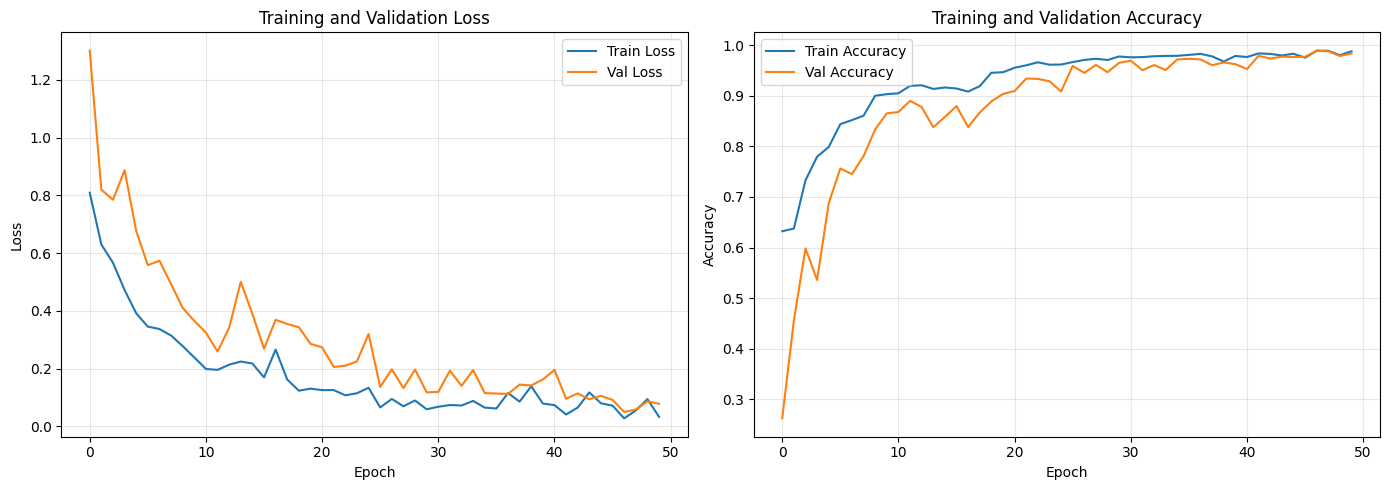

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nEvaluating CNN model on test set...")

# Load best model
cnn_model = keras.models.load_model(checkpoint_path)

# Predictions
y_pred_proba = cnn_model.predict(X_test_raw, batch_size=32)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred, target_names=['Non-Seizure', 'Seizure']))

# Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred)
print("\nConfusion Matrix:")
print(cm)


Evaluating CNN model on test set...
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step

Classification Report:
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.99      0.99      5591
     Seizure       0.11      0.35      0.17        23

    accuracy                           0.99      5614
   macro avg       0.55      0.67      0.58      5614
weighted avg       0.99      0.99      0.99      5614


Confusion Matrix:
[[5528   63]
 [  15    8]]


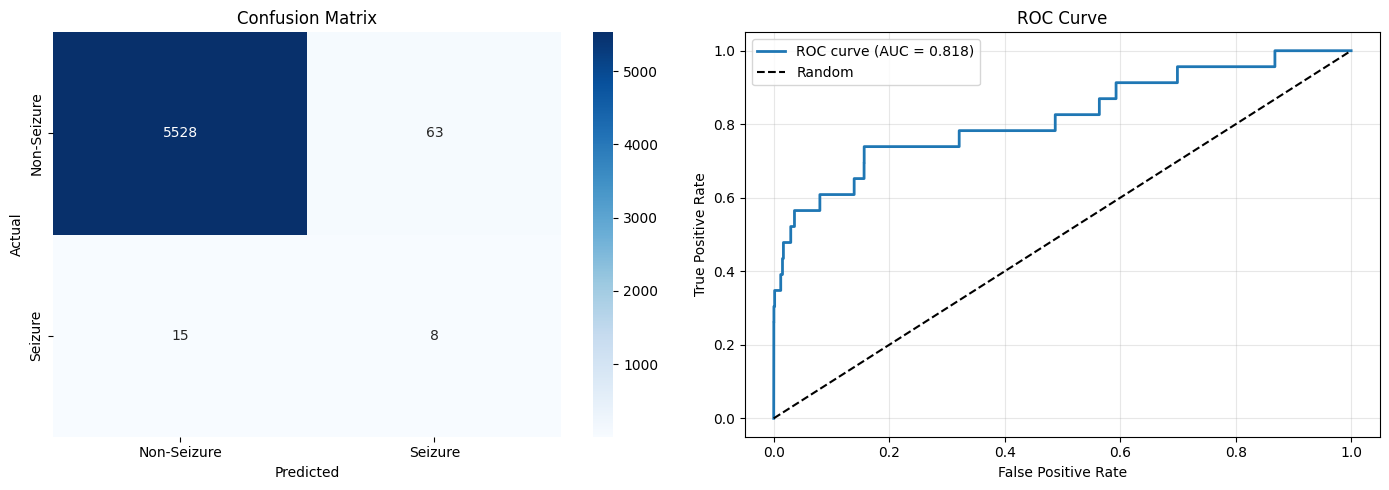


ROC AUC Score: 0.8184


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Seizure', 'Seizure'],
            yticklabels=['Non-Seizure', 'Seizure'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_raw, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")

In [ ]:
results = {
    'test_loss': cnn_model.evaluate(X_test_raw, y_test_raw, verbose=0)[0],
    'test_accuracy': cnn_model.evaluate(X_test_raw, y_test_raw, verbose=0)[1],
    'roc_auc': roc_auc,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(y_test_raw, y_pred, output_dict=True)
}

import json
results_path = '/content/drive/MyDrive/Datasets_ML/model_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\nResults saved to: {results_path}")


Results saved to: /content/drive/MyDrive/Datasets_ML/model_results.json


Testing using Bonn Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import gc
import warnings
import os
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
bonn_data_path_set_a = '/content/drive/MyDrive/Datasets_ML/Z/'
bonn_data_path_set_b = '/content/drive/MyDrive/Datasets_ML/O/'
bonn_data_path_set_c = '/content/drive/MyDrive/Datasets_ML/N/'
bonn_data_path_set_d = '/content/drive/MyDrive/Datasets_ML/F/'
bonn_data_path_set_e = '/content/drive/MyDrive/Datasets_ML/S/'

In [ ]:
# Get all files from each set
set_a_files = sorted([f for f in os.listdir(bonn_data_path_set_a) if f.endswith('.txt')])
set_b_files = sorted([f for f in os.listdir(bonn_data_path_set_b) if f.endswith('.txt')])
set_c_files = sorted([f for f in os.listdir(bonn_data_path_set_c) if f.endswith('.txt')])
set_d_files = sorted([f for f in os.listdir(bonn_data_path_set_d) if f.endswith('.txt')])
set_e_files = sorted([f for f in os.listdir(bonn_data_path_set_e) if f.endswith('.txt')])

print(f"\nFiles found:")
print(f"Set A: {len(set_a_files)} files")
print(f"Set B: {len(set_b_files)} files")
print(f"Set C: {len(set_c_files)} files")
print(f"Set D: {len(set_d_files)} files")
print(f"Set E: {len(set_e_files)} files")

def load_bonn_file(filepath):
    """Load single Bonn EEG file"""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            data.append(float(line.strip()))
    return np.array(data)

# Load all files
print("\nLoading Bonn dataset files...")
bonn_data = []
bonn_labels = []
bonn_filenames = []
bonn_set_names = []

# Load Set A (non-seizure)
print("\nLoading Set A (Non-Seizure - Healthy, Eyes Open):")
for filename in set_a_files:
    filepath = bonn_data_path_set_a + filename
    try:
        segment = load_bonn_file(filepath)
        bonn_data.append(segment)
        bonn_labels.append(0)
        bonn_filenames.append(filename)
        bonn_set_names.append('A')
    except Exception as e:
        print(f"Error loading {filename}: {e}")
print(f"Loaded {len(set_a_files)} files from Set A")

# Load Set B (non-seizure)
print("\nLoading Set B (Non-Seizure - Healthy, Eyes Closed):")
for filename in set_b_files:
    filepath = bonn_data_path_set_b + filename
    try:
        segment = load_bonn_file(filepath)
        bonn_data.append(segment)
        bonn_labels.append(0)
        bonn_filenames.append(filename)
        bonn_set_names.append('B')
    except Exception as e:
        print(f"Error loading {filename}: {e}")
print(f"Loaded {len(set_b_files)} files from Set B")

# Load Set C (non-seizure)
print("\nLoading Set C (Non-Seizure - Epilepsy Patient, Seizure-Free, Hippocampal):")
for filename in set_c_files:
    filepath = bonn_data_path_set_c + filename
    try:
        segment = load_bonn_file(filepath)
        bonn_data.append(segment)
        bonn_labels.append(0)
        bonn_filenames.append(filename)
        bonn_set_names.append('C')
    except Exception as e:
        print(f"Error loading {filename}: {e}")
print(f"Loaded {len(set_c_files)} files from Set C")

# Load Set D (non-seizure)
print("\nLoading Set D (Non-Seizure - Epilepsy Patient, Seizure-Free, Non-Hippocampal):")
for filename in set_d_files:
    filepath = bonn_data_path_set_d + filename
    try:
        segment = load_bonn_file(filepath)
        bonn_data.append(segment)
        bonn_labels.append(0)
        bonn_filenames.append(filename)
        bonn_set_names.append('D')
    except Exception as e:
        print(f"Error loading {filename}: {e}")
print(f"Loaded {len(set_d_files)} files from Set D")

# Load Set E (seizure)
print("\nLoading Set E (Seizure):")
for filename in set_e_files:
    filepath = bonn_data_path_set_e + filename
    try:
        segment = load_bonn_file(filepath)
        bonn_data.append(segment)
        bonn_labels.append(1)
        bonn_filenames.append(filename)
        bonn_set_names.append('E')
    except Exception as e:
        print(f"Error loading {filename}: {e}")
print(f"Loaded {len(set_e_files)} files from Set E")

bonn_data = np.array(bonn_data)
bonn_labels = np.array(bonn_labels)
bonn_set_names = np.array(bonn_set_names)

print(f"\nBonn dataset loaded:")
print(f"Total segments: {len(bonn_data)}")
print(f"Shape: {bonn_data.shape}")
print(f"Seizure segments (Set E): {np.sum(bonn_labels == 1)}")
print(f"Non-seizure segments (Sets A-D): {np.sum(bonn_labels == 0)}")
print(f"\nClass distribution:")
print(f"  Set A: {np.sum(bonn_set_names == 'A')} segments")
print(f"  Set B: {np.sum(bonn_set_names == 'B')} segments")
print(f"  Set C: {np.sum(bonn_set_names == 'C')} segments")
print(f"  Set D: {np.sum(bonn_set_names == 'D')} segments")
print(f"  Set E: {np.sum(bonn_set_names == 'E')} segments")


Files found:
Set A: 100 files
Set B: 100 files
Set C: 0 files
Set D: 100 files
Set E: 100 files

Loading Bonn dataset files...

Loading Set A (Non-Seizure - Healthy, Eyes Open):
Loaded 100 files from Set A

Loading Set B (Non-Seizure - Healthy, Eyes Closed):
Loaded 100 files from Set B

Loading Set C (Non-Seizure - Epilepsy Patient, Seizure-Free, Hippocampal):
Loaded 0 files from Set C

Loading Set D (Non-Seizure - Epilepsy Patient, Seizure-Free, Non-Hippocampal):
Loaded 100 files from Set D

Loading Set E (Seizure):
Loaded 100 files from Set E

Bonn dataset loaded:
Total segments: 400
Shape: (400, 4097)
Seizure segments (Set E): 100
Non-seizure segments (Sets A-D): 300

Class distribution:
  Set A: 100 segments
  Set B: 100 segments
  Set C: 0 segments
  Set D: 100 segments
  Set E: 100 segments


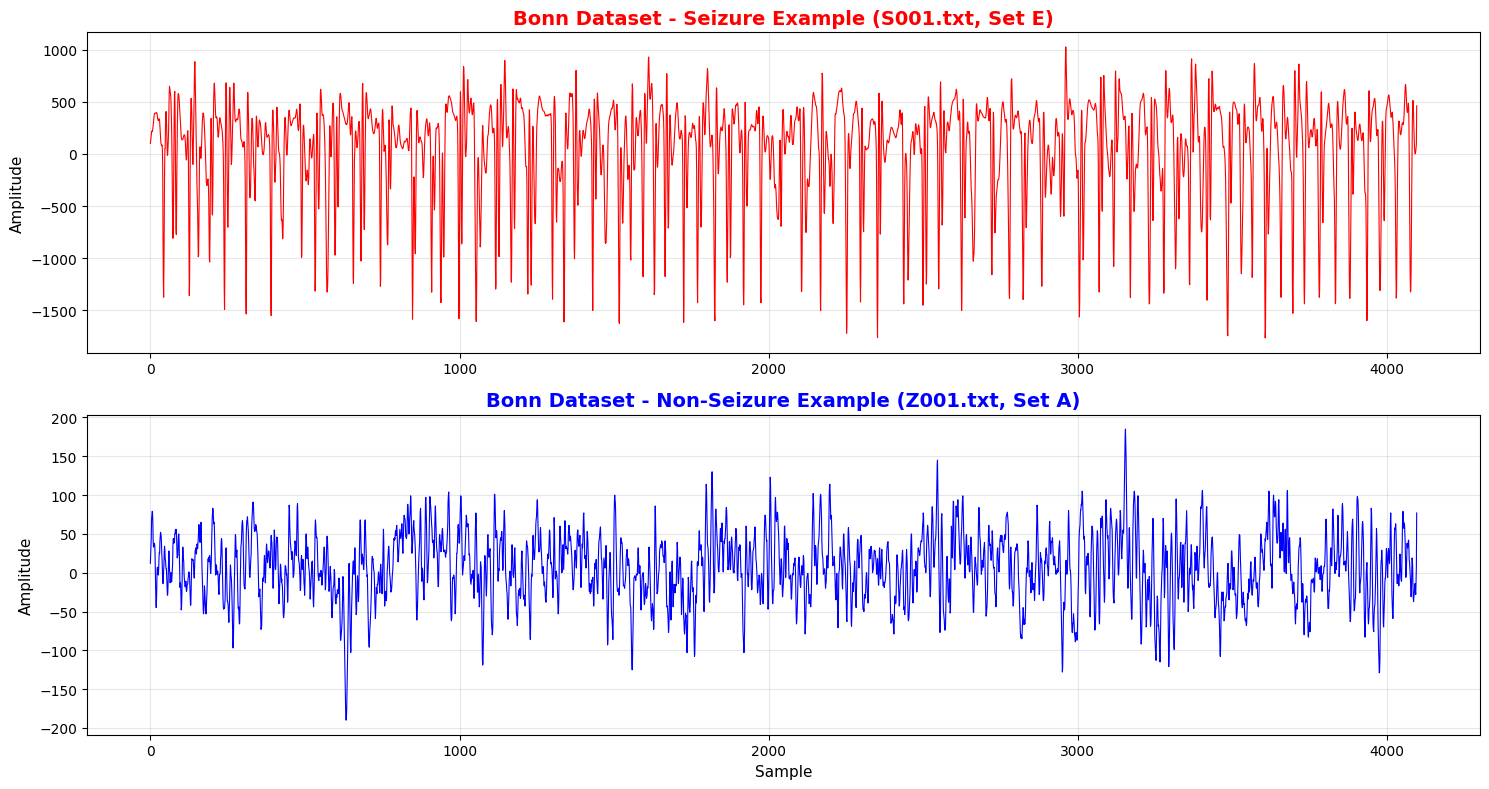

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

seizure_idx = np.where(bonn_labels == 1)[0][0]
axes[0].plot(bonn_data[seizure_idx], linewidth=0.8, color='red')
axes[0].set_title(f'Bonn Dataset - Seizure Example ({bonn_filenames[seizure_idx]}, Set E)',
                  fontsize=14, color='red', fontweight='bold')
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].grid(True, alpha=0.3)

non_seizure_idx = np.where(bonn_labels == 0)[0][0]
axes[1].plot(bonn_data[non_seizure_idx], linewidth=0.8, color='blue')
axes[1].set_title(f'Bonn Dataset - Non-Seizure Example ({bonn_filenames[non_seizure_idx]}, Set A)',
                  fontsize=14, color='blue', fontweight='bold')
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_xlabel('Sample', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import signal # Added this line

class BonnPreprocessor:
    def __init__(self, lowcut=0.5, highcut=50.0, fs=173.61):
        self.lowcut = lowcut
        self.highcut = highcut
        self.fs = fs

    def bandpass_filter(self, data):
        nyquist = self.fs / 2
        low = self.lowcut / nyquist
        high = self.highcut / nyquist

        b, a = signal.butter(4, [low, high], btype='band')
        filtered_data = signal.filtfilt(b, a, data)

        return filtered_data

    def normalize(self, data):
        mean = np.mean(data)
        std = np.std(data)
        return (data - mean) / (std + 1e-8)

bonn_preprocessor = BonnPreprocessor(lowcut=0.5, highcut=50.0, fs=173.61)

print("Preprocessing Bonn data...")
bonn_processed = []

for i, segment in enumerate(bonn_data):
    filtered = bonn_preprocessor.bandpass_filter(segment)
    normalized = bonn_preprocessor.normalize(filtered)
    bonn_processed.append(normalized)

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(bonn_data)} files")

bonn_processed = np.array(bonn_processed)

print(f"\nBonn preprocessed shape: {bonn_processed.shape}")


Preprocessing Bonn data...
Processed 20/400 files
Processed 40/400 files
Processed 60/400 files
Processed 80/400 files
Processed 100/400 files
Processed 120/400 files
Processed 140/400 files
Processed 160/400 files
Processed 180/400 files
Processed 200/400 files
Processed 220/400 files
Processed 240/400 files
Processed 260/400 files
Processed 280/400 files
Processed 300/400 files
Processed 320/400 files
Processed 340/400 files
Processed 360/400 files
Processed 380/400 files
Processed 400/400 files

Bonn preprocessed shape: (400, 4097)


In [ ]:
nan_count = np.isnan(bonn_processed).sum()
inf_count = np.isinf(bonn_processed).sum()

print(f"NaN values found: {nan_count}")
print(f"Infinite values found: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("Handling missing/infinite values...")
    bonn_processed = np.nan_to_num(bonn_processed, nan=0.0, posinf=0.0, neginf=0.0)
    print("Missing values handled")
else:
    print("No missing values found - data is clean")

NaN values found: 0
Infinite values found: 0
No missing values found - data is clean


In [ ]:
bonn_reshaped = bonn_processed[:, :, np.newaxis]
print(f"\nBonn reshaped for CNN: {bonn_reshaped.shape}")
print("Format: (segments, timesteps, features)")


Bonn reshaped for CNN: (400, 4097, 1)
Format: (segments, timesteps, features)


In [ ]:
# Splitting the Dataset for Training and testing
X_train, X_temp, y_train, y_temp = train_test_split(
    bonn_reshaped, bonn_labels,
    test_size=0.3,
    random_state=42,
    stratify=bonn_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train set: {X_train.shape}, Labels: {np.bincount(y_train)}")
print(f"Val set: {X_val.shape}, Labels: {np.bincount(y_val)}")
print(f"Test set: {X_test.shape}, Labels: {np.bincount(y_test)}")

del X_temp, y_temp
gc.collect()

Train set: (280, 4097, 1), Labels: [210  70]
Val set: (60, 4097, 1), Labels: [45 15]
Test set: (60, 4097, 1), Labels: [45 15]


3

In [ ]:
print("\nBuilding CNN model")

def build_bonn_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])

    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # Corrected input shape
model = build_bonn_cnn_model(input_shape)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Summary:")
model.summary()


Building CNN model

Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 4095, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4095, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 2045, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2045, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 1020, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1020, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65280)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,355,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,396,737 (32.03 MB)

 Trainable params: 8,396,033 (32.03 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
model_type = 'CNN'

input_shape = (X_train.shape[1], X_train.shape[2]) # Corrected input shape

# Clear any old Keras session state to prevent tf.function related errors
tf.keras.backend.clear_session()

if model_type == 'CNN':
    model = build_bonn_cnn_model(input_shape)
    print("\nUsing CNN model")
else:
    model = build_bonn_lstm_model(input_shape)
    print("\nUsing LSTM model")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"\n{model_type} Model Summary:")
model.summary()


Using CNN model

CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4095, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4095, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2045, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2045, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1020, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1020, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65280)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,355,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,396,737 (32.03 MB)

 Trainable params: 8,396,033 (32.03 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

checkpoint_path = f'/content/drive/MyDrive/Datasets_ML/bonn_{model_type.lower()}_model.keras'
model_checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weights_dict}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("\nTraining complete")

Class weights: {0: np.float64(0.6666666666666666), 1: np.float64(2.0)}
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.7384 - loss: 0.4796 - precision: 0.4579 - recall: 0.7944
Epoch 1: val_loss improved from inf to 3.66471, saving model to /content/drive/MyDrive/Datasets_ML/bonn_cnn_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 789ms/step - accuracy: 0.7403 - loss: 0.4777 - precision: 0.4618 - recall: 0.7962 - val_accuracy: 0.2500 - val_loss: 3.6647 - val_precision: 0.2500 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8860 - loss: 0.3376 - precision: 0.8038 - recall: 0.8417
Epoch 2: val_loss did not improve from 3.66471
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 490ms/step - accuracy: 0.8845 - loss: 0.3379 - precision: 0.7964 - recall: 0.8433 - val_accuracy: 0.2500 - val_loss: 5.9651 - val_precision: 0.2500 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.89

In [ ]:
# Wait until your CHB-MIT model finishes training, then run this cell

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load the trained model
model_path = '/content/drive/MyDrive/Datasets_ML/best_cnn_model.keras'
trained_model = keras.models.load_model(model_path)

print("Trained CHB-MIT model loaded")

Trained CHB-MIT model loaded


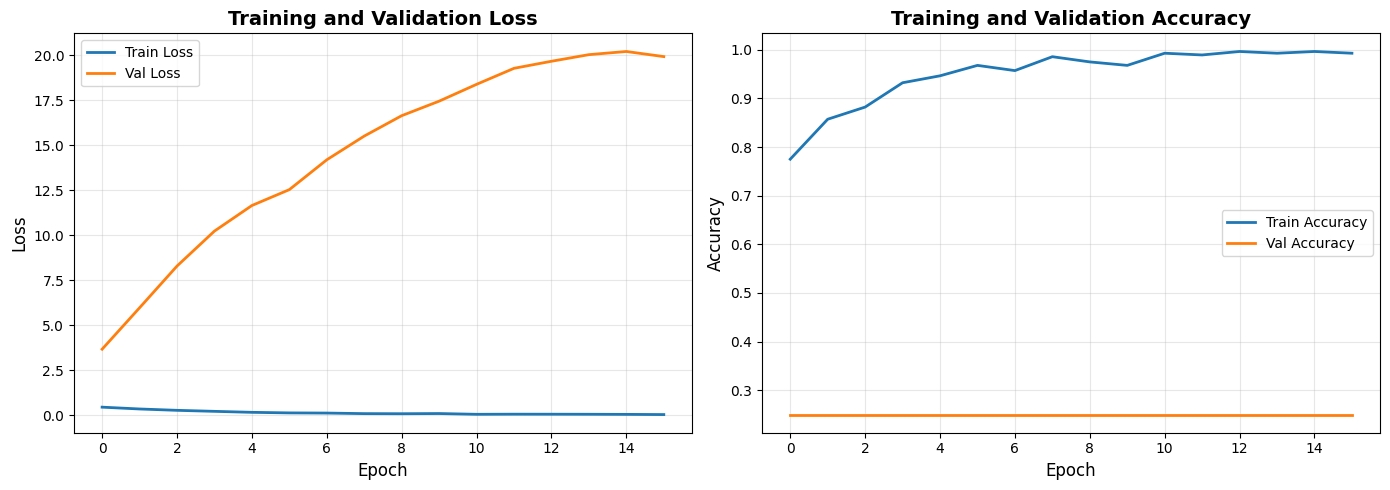

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Testing the CHB Model

# Reshape Bonn data to match CHB-MIT model input requirements
# Model expects (batch_size, 23, 640)

# bonn_reshaped is (400, 4097, 1) -> (samples, timepoints, channels)

# Step 1: Transpose to (samples, channels, timepoints)
bonn_transposed = np.transpose(bonn_reshaped, (0, 2, 1)) # (400, 1, 4097)

# Step 2: Repeat the single channel to 23 channels
bonn_multi_channel = np.repeat(bonn_transposed, 23, axis=1) # (400, 23, 4097)

# Step 3: Trim/slice timepoints to 640
bonn_final_input = bonn_multi_channel[:, :, :640] # (400, 23, 640)

print(f"Adapted Bonn data shape for CNN: {bonn_final_input.shape}")

y_pred_proba = trained_model.predict(bonn_final_input, batch_size=32)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Evaluation
print("\nClassification Report (Bonn Test Set):")
print(classification_report(bonn_labels, y_pred, target_names=['Non-Seizure', 'Seizure']))

# Confusion Matrix
cm = confusion_matrix(bonn_labels, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(bonn_labels, y_pred)
precision = precision_score(bonn_labels, y_pred)
recall = recall_score(bonn_labels, y_pred)
f1 = f1_score(bonn_labels, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Adapted Bonn data shape for CNN: (400, 23, 640)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

Classification Report (Bonn Test Set):
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.01      0.02       300
     Seizure       0.25      1.00      0.40       100

    accuracy                           0.26       400
   macro avg       0.63      0.51      0.21       400
weighted avg       0.81      0.26      0.12       400


Confusion Matrix:
[[  3 297]
 [  0 100]]

Accuracy: 0.2575
Precision: 0.2519
Recall: 1.0000
F1-Score: 0.4024


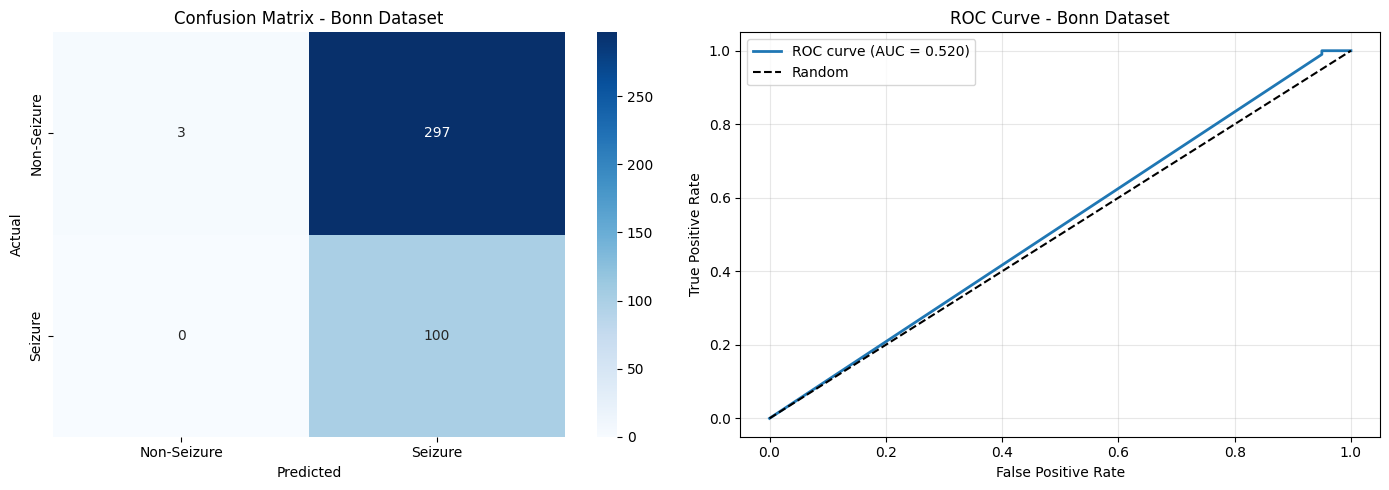


ROC AUC Score: 0.5203


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Seizure', 'Seizure'],
            yticklabels=['Non-Seizure', 'Seizure'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - Bonn Dataset')

# ROC Curve
fpr, tpr, _ = roc_curve(bonn_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Bonn Dataset')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")